# E-Commerce Customer Behavior Analysis

In [5]:
# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
# Load Dataset
df = pd.read_csv("../data/raw/ecommerce_customer_behavior.csv")

In [7]:
# Display first five rows
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


In [8]:
# Display last five rows
df.tail()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
24995,4516,24995,21-07-2024,1,0,0,181,0,688.68,3,...,1,0,0,21,7,6,2,Short,0.0,5
24996,9794,24996,27-12-2024,1,1,1,363,5,206.69,4,...,1,0,1,27,12,4,3,Very Long,0.0,128
24997,3082,24997,28-02-2024,2,0,1,888,2,1345.97,4,...,1,0,4,28,2,2,3,Very Short,0.0,56
24998,6219,24998,23-04-2024,1,0,4,840,4,182.81,1,...,1,0,1,23,4,1,1,Very Short,0.0,91
24999,2962,24999,21-08-2024,2,0,5,22,4,83.21,4,...,1,0,0,21,8,2,2,Short,0.0,198


In [9]:
# Shape of Dataset
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 25000
Columns : 29


In [10]:
# Column Names
df.columns.tolist()

['customer_id',
 'session_id',
 'visit_date',
 'device_type',
 'user_type',
 'marketing_channel',
 'product_id',
 'product_category',
 'unit_price',
 'quantity',
 'discount_percent',
 'discount_amount',
 'revenue',
 'pages_viewed',
 'time_on_site_sec',
 'added_to_cart',
 'purchased',
 'cart_abandoned',
 'rating',
 'review_text',
 'review_helpful_votes',
 'payment_method',
 'visit_day',
 'visit_month',
 'visit_weekday',
 'visit_season',
 'session_duration_bucket',
 'revenue_normalized',
 'location']

In [11]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [12]:
# Statistical Summary
df.describe()

,customer_id,session_id,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,...,rating,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,revenue_normalized,location
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,...,25000.00000,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,5479.930600,12499.500000,0.705040,0.551280,2.514040,449.107000,3.495240,782.319010,2.489040,8.99880,...,3.94800,1.67488,5.52080,2.483160,15.714520,6.510520,2.980800,1.504400,0.051290,111.70692
std,2593.544596,7217.022701,0.639543,0.497373,1.704934,259.513787,2.285053,476.612168,1.114563,9.26364,...,0.54047,1.98673,12.33629,1.709501,8.796338,3.457925,1.992554,1.117475,0.129591,65.07079
min,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.050000,1.000000,0.00000,...,1.00000,0.00000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,3234.000000,6249.750000,0.000000,0.000000,1.000000,225.000000,2.000000,395.222500,1.000000,0.00000,...,4.00000,1.00000,0.00000,1.000000,8.000000,3.000000,1.000000,1.000000,0.000000,55.00000
50%,5482.000000,12499.500000,1.000000,1.000000,2.000000,448.000000,4.000000,691.725000,2.000000,10.00000,...,4.00000,1.00000,0.00000,2.000000,16.000000,7.000000,3.000000,2.000000,0.000000,111.00000
75%,7715.000000,18749.250000,1.000000,1.000000,4.000000,675.000000,5.000000,1096.842500,3.000000,15.00000,...,4.00000,1.00000,0.00000,4.000000,23.000000,10.000000,5.000000,3.000000,0.000000,169.00000
max,9998.000000,24999.000000,2.000000,1.000000,5.000000,898.000000,7.000000,1999.830000,4.000000,30.00000,...,5.00000,10.00000,49.00000,5.000000,31.000000,12.000000,6.000000,3.000000,1.000000,224.00000


In [13]:
# Missing Values
df.isnull().sum()

customer_id                0
session_id                 0
visit_date                 0
device_type                0
user_type                  0
marketing_channel          0
product_id                 0
product_category           0
unit_price                 0
quantity                   0
discount_percent           0
discount_amount            0
revenue                    0
pages_viewed               0
time_on_site_sec           0
added_to_cart              0
purchased                  0
cart_abandoned             0
rating                     0
review_text                0
review_helpful_votes       0
payment_method             0
visit_day                  0
visit_month                0
visit_weekday              0
visit_season               0
session_duration_bucket    0
revenue_normalized         0
location                   0
dtype: int64

In [14]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

In [15]:
# Data Types
df.dtypes

customer_id                  int64
session_id                   int64
visit_date                  object
device_type                  int64
user_type                    int64
marketing_channel            int64
product_id                   int64
product_category             int64
unit_price                 float64
quantity                     int64
discount_percent             int64
discount_amount            float64
revenue                    float64
pages_viewed                 int64
time_on_site_sec             int64
added_to_cart                int64
purchased                    int64
cart_abandoned               int64
rating                       int64
review_text                  int64
review_helpful_votes         int64
payment_method               int64
visit_day                    int64
visit_month                  int64
visit_weekday                int64
visit_season                 int64
session_duration_bucket     object
revenue_normalized         float64
location            

In [16]:
df.nunique().sort_values()

user_type                      2
added_to_cart                  2
cart_abandoned                 2
purchased                      2
device_type                    3
session_duration_bucket        4
visit_season                   4
quantity                       4
rating                         5
marketing_channel              6
payment_method                 6
visit_weekday                  7
discount_percent               7
product_category               8
review_text                   11
visit_month                   12
pages_viewed                  24
visit_day                     31
review_helpful_votes          50
location                     225
visit_date                   365
product_id                   899
time_on_site_sec            1790
revenue                     5573
revenue_normalized          5573
customer_id                 8442
discount_amount            13189
unit_price                 23136
session_id                 25000
dtype: int64

In [17]:
df.nunique().sort_values().to_frame("Unique Values")

,Unique Values
user_type,2
added_to_cart,2
cart_abandoned,2
purchased,2
device_type,3
session_duration_bucket,4
visit_season,4
quantity,4
rating,5
marketing_channel,6


In [18]:
df["visit_date"] = pd.to_datetime(df["visit_date"], dayfirst=True)

In [19]:
df["visit_date"].dtype

dtype('<M8[ns]')

In [20]:
categorical_columns = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "payment_method",
    "session_duration_bucket",
    "visit_season"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


device_type
device_type
1    12600
0     9887
2     2513
Name: count, dtype: int64

user_type
user_type
1    13782
0    11218
Name: count, dtype: int64

marketing_channel
marketing_channel
2    4281
5    4263
1    4190
3    4116
4    4109
0    4041
Name: count, dtype: int64

product_category
product_category
2    3237
4    3204
5    3149
0    3142
6    3112
7    3073
1    3043
3    3040
Name: count, dtype: int64

payment_method
payment_method
1    4281
4    4229
0    4227
3    4140
5    4072
2    4051
Name: count, dtype: int64

session_duration_bucket
session_duration_bucket
Very Short    6270
Long          6254
Very Long     6240
Short         6236
Name: count, dtype: int64

visit_season
visit_season
3    6275
2    6269
1    6247
0    6209
Name: count, dtype: int64


In [21]:
df["purchased"].value_counts()

purchased
0    19384
1     5616
Name: count, dtype: int64

In [22]:
purchase_percentage = (
    df["purchased"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(purchase_percentage)

purchased
0    77.54
1    22.46
Name: proportion, dtype: float64


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              25000 non-null  int64         
 1   session_id               25000 non-null  int64         
 2   visit_date               25000 non-null  datetime64[ns]
 3   device_type              25000 non-null  int64         
 4   user_type                25000 non-null  int64         
 5   marketing_channel        25000 non-null  int64         
 6   product_id               25000 non-null  int64         
 7   product_category         25000 non-null  int64         
 8   unit_price               25000 non-null  float64       
 9   quantity                 25000 non-null  int64         
 10  discount_percent         25000 non-null  int64         
 11  discount_amount          25000 non-null  float64       
 12  revenue                  25000 n

In [24]:
df.to_csv("../data/processed/cleaned_ecommerce.csv", index=False)

## Feature Classification

Before performing Exploratory Data Analysis (EDA), the dataset features are classified into different categories. This helps determine the appropriate analysis and preprocessing techniques for each feature.

The features are categorized as:

- Identifier Features
- Numerical Features
- Categorical Features
- Date Feature
- Target Feature

In [25]:
# Identifier Columns

identifier_columns = [
    "customer_id",
    "session_id",
    "product_id"
]

# Numerical Columns

numerical_columns = [
    "unit_price",
    "quantity",
    "discount_percent",
    "discount_amount",
    "revenue",
    "pages_viewed",
    "time_on_site_sec",
    "review_helpful_votes",
    "revenue_normalized"
]

# Categorical Columns

categorical_columns = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "added_to_cart",
    "cart_abandoned",
    "rating",
    "review_text",
    "payment_method",
    "visit_day",
    "visit_month",
    "visit_weekday",
    "visit_season",
    "session_duration_bucket",
    "location"
]

# Date Column

date_column = "visit_date"

# Target Column

target_column = "purchased"

In [26]:
print("Identifier Columns:", len(identifier_columns))
print("Numerical Columns:", len(numerical_columns))
print("Categorical Columns:", len(categorical_columns))
print("Date Column:", date_column)
print("Target Column:", target_column)

Identifier Columns: 3
Numerical Columns: 9
Categorical Columns: 15
Date Column: visit_date
Target Column: purchased


### Target Variable Analysis

The target variable of this project is **`purchased`**, which indicates whether a customer completed a purchase during a session.

- **0** → Customer did not purchase
- **1** → Customer purchased

Understanding the distribution of the target variable is important because:

- It helps identify class imbalance.
- It determines suitable evaluation metrics.
- It provides an overview of the dataset before model training.

In [27]:
purchase_counts = df["purchased"].value_counts()
purchase_counts

purchased
0    19384
1     5616
Name: count, dtype: int64

In [28]:
purchase_percentage = (
    df["purchased"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

purchase_percentage

purchased
0    77.54
1    22.46
Name: proportion, dtype: float64

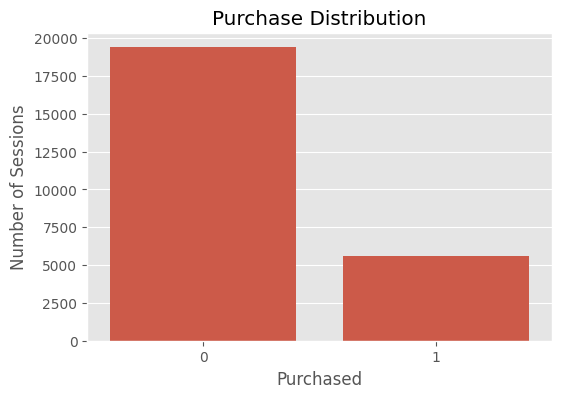

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="purchased"
)

plt.title("Purchase Distribution")
plt.xlabel("Purchased")
plt.ylabel("Number of Sessions")

plt.show()

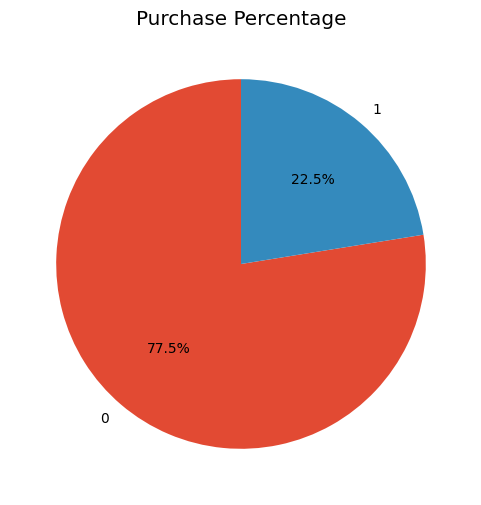

In [30]:
plt.figure(figsize=(6,6))

df["purchased"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Purchase Percentage")

plt.show()

### Numerical Feature Analysis

In this section, we analyze numerical variables to understand their distribution, variability, and potential impact on customer purchasing behavior.

The analysis focuses on:

- Revenue
- Unit Price
- Quantity
- Discount
- Pages Viewed
- Time on Site

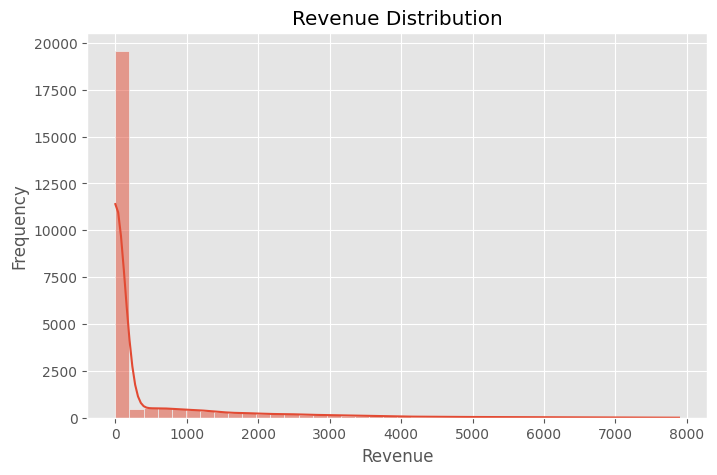

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["revenue"],
    bins=40,
    kde=True
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

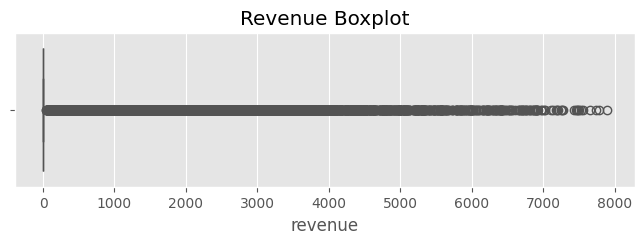

In [32]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["revenue"]
)

plt.title("Revenue Boxplot")

plt.show()

In [33]:
df["revenue"].describe()

count    25000.000000
mean       404.646762
std       1022.391774
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       7889.360000
Name: revenue, dtype: float64

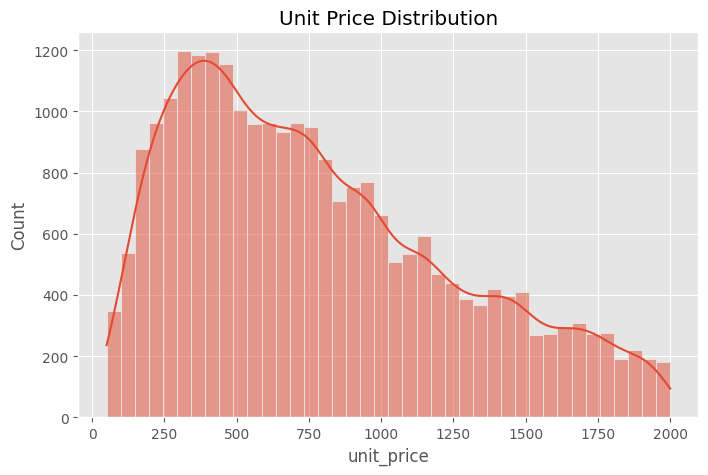

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["unit_price"],
    bins=40,
    kde=True
)

plt.title("Unit Price Distribution")

plt.show()

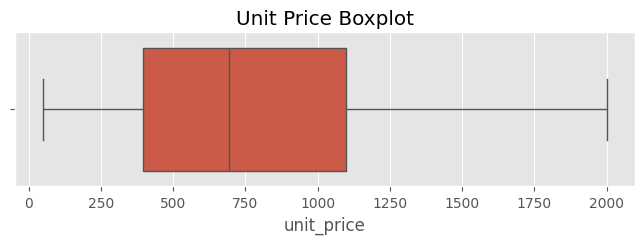

In [35]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["unit_price"]
)

plt.title("Unit Price Boxplot")

plt.show()

In [36]:
df["unit_price"].describe()

count    25000.000000
mean       782.319010
std        476.612168
min         50.050000
25%        395.222500
50%        691.725000
75%       1096.842500
max       1999.830000
Name: unit_price, dtype: float64

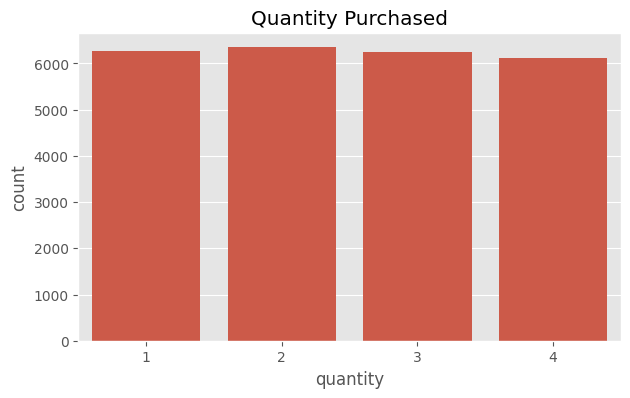

In [37]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="quantity"
)

plt.title("Quantity Purchased")

plt.show()

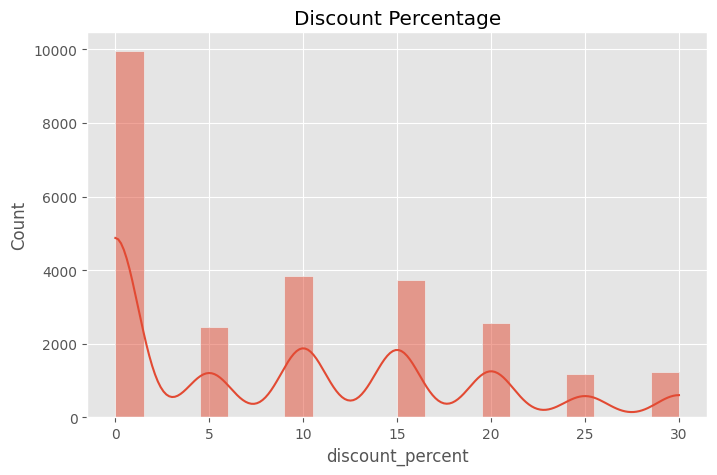

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["discount_percent"],
    bins=20,
    kde=True
)

plt.title("Discount Percentage")

plt.show()

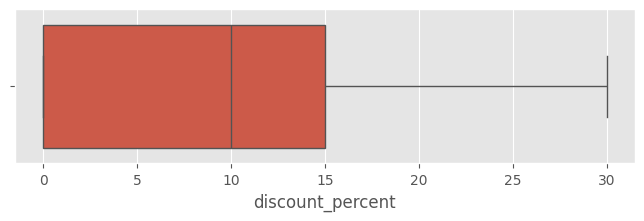

In [39]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["discount_percent"]
)

plt.show()

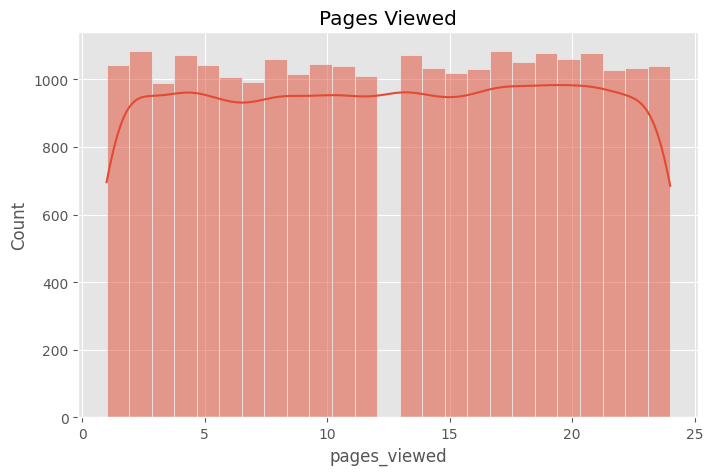

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["pages_viewed"],
    bins=25,
    kde=True
)

plt.title("Pages Viewed")

plt.show()

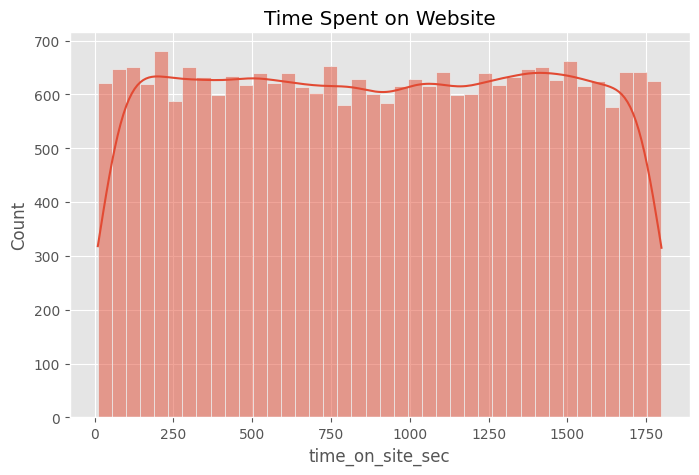

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["time_on_site_sec"],
    bins=40,
    kde=True
)

plt.title("Time Spent on Website")

plt.show()

## Relationship Analysis

This section explores how different customer behaviors and session characteristics influence purchase decisions.

Instead of analyzing features independently, each feature is compared with the target variable (`purchased`) to identify factors that contribute to successful conversions.

The objective is to answer questions such as:

- Which device generates the highest purchase rate?
- Which marketing channel is most effective?
- Does spending more time on the website increase conversions?
- How does discount affect purchases?

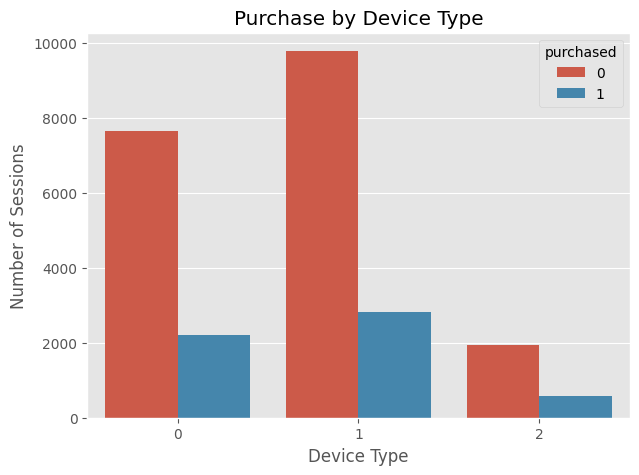

In [42]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="device_type",
    hue="purchased"
)

plt.title("Purchase by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Number of Sessions")

plt.show()

In [43]:
device_purchase = pd.crosstab(
    df["device_type"],
    df["purchased"],
    normalize="index"
) * 100

device_purchase.round(2)

purchased,0,1
device_type,,
0,77.54,22.46
1,77.68,22.32
2,76.80,23.20


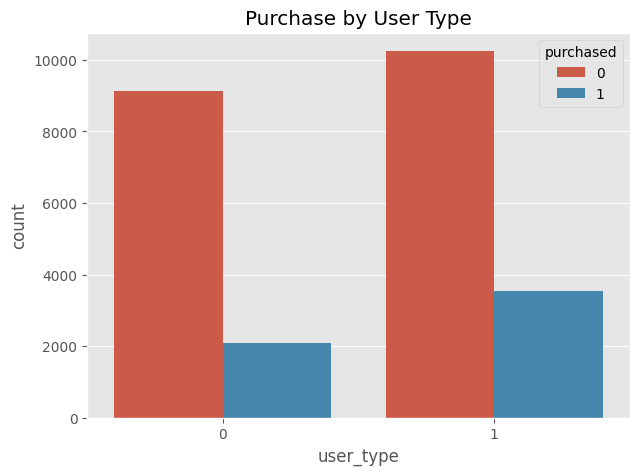

In [44]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="user_type",
    hue="purchased"
)

plt.title("Purchase by User Type")

plt.show()

In [45]:
pd.crosstab(
    df["user_type"],
    df["purchased"],
    normalize="index"
).round(3) * 100

purchased,0,1
user_type,,
0,81.4,18.6
1,74.4,25.6


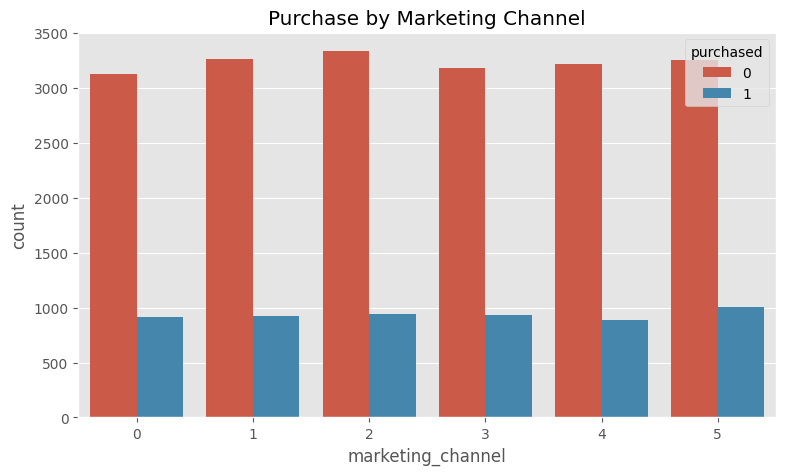

In [46]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="marketing_channel",
    hue="purchased"
)

plt.title("Purchase by Marketing Channel")

plt.show()

In [47]:
pd.crosstab(
    df["marketing_channel"],
    df["purchased"],
    normalize="index"
).round(2) * 100

purchased,0,1
marketing_channel,,
0,77.0,23.0
1,78.0,22.0
2,78.0,22.0
3,77.0,23.0
4,78.0,22.0
5,76.0,24.0


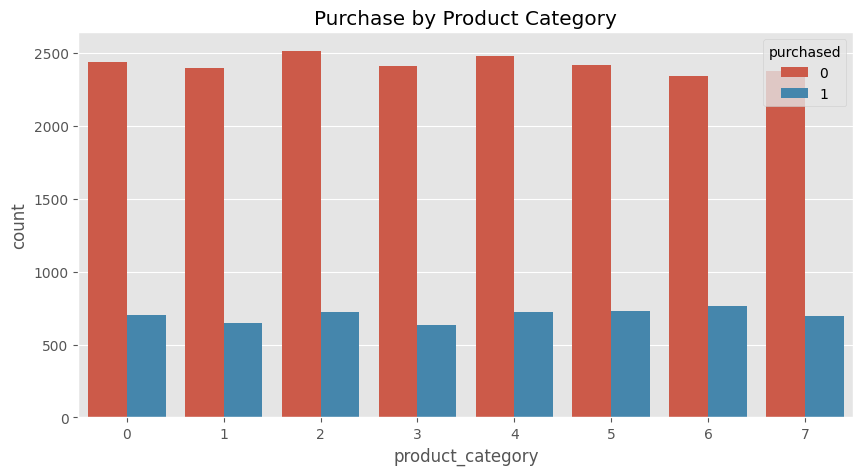

In [48]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="product_category",
    hue="purchased"
)

plt.title("Purchase by Product Category")

plt.show()

In [49]:
pd.crosstab(
    df["product_category"],
    df["purchased"],
    normalize="index"
).round(2) * 100

purchased,0,1
product_category,,
0,78.0,22.0
1,79.0,21.0
2,78.0,22.0
3,79.0,21.0
4,77.0,23.0
5,77.0,23.0
6,75.0,25.0
7,77.0,23.0


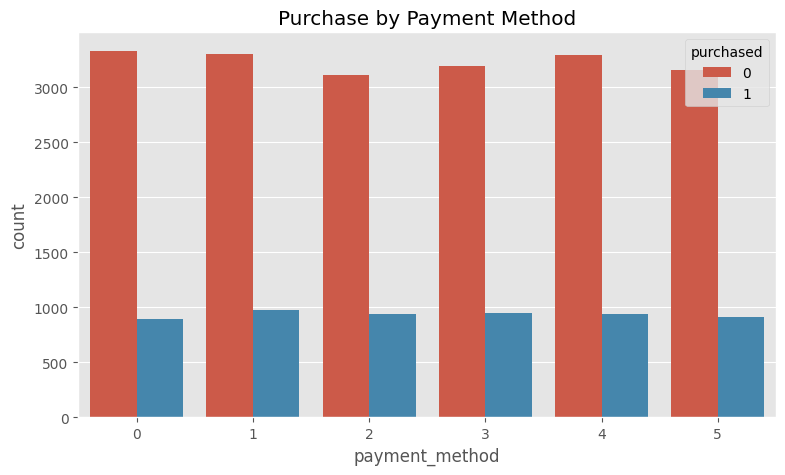

In [50]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="payment_method",
    hue="purchased"
)

plt.title("Purchase by Payment Method")

plt.show()

In [51]:
pd.crosstab(
    df["payment_method"],
    df["purchased"],
    normalize="index"
).round(2) * 100

purchased,0,1
payment_method,,
0,79.0,21.0
1,77.0,23.0
2,77.0,23.0
3,77.0,23.0
4,78.0,22.0
5,78.0,22.0


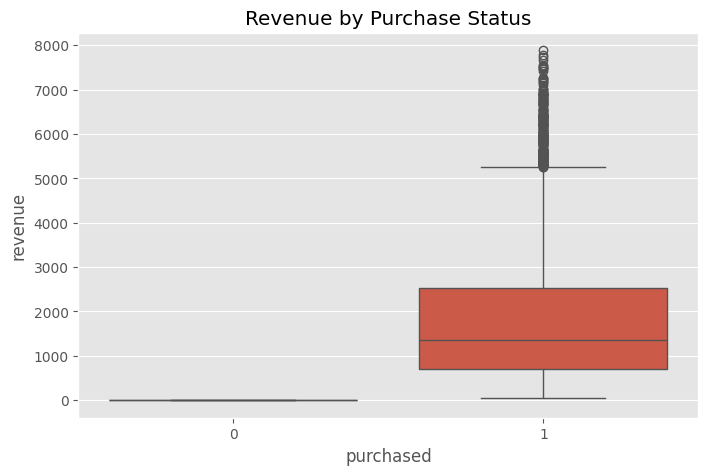

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="purchased",
    y="revenue"
)

plt.title("Revenue by Purchase Status")

plt.show()

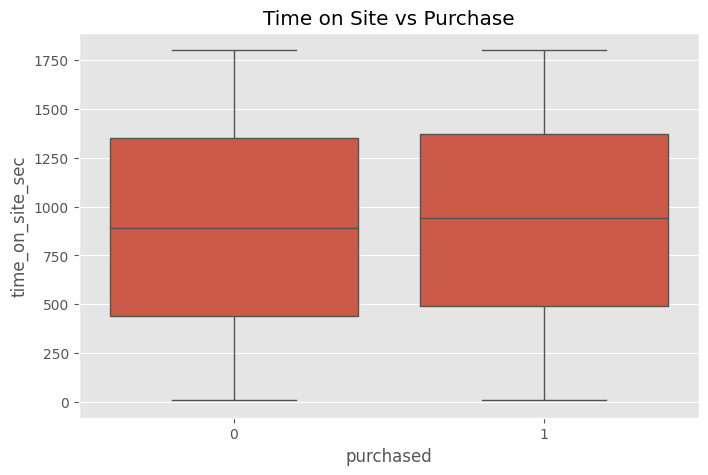

In [53]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="purchased",
    y="time_on_site_sec"
)

plt.title("Time on Site vs Purchase")

plt.show()

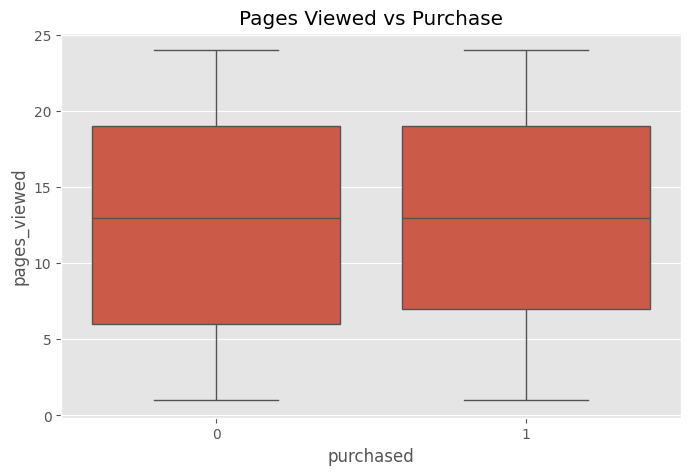

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="purchased",
    y="pages_viewed"
)

plt.title("Pages Viewed vs Purchase")

plt.show()

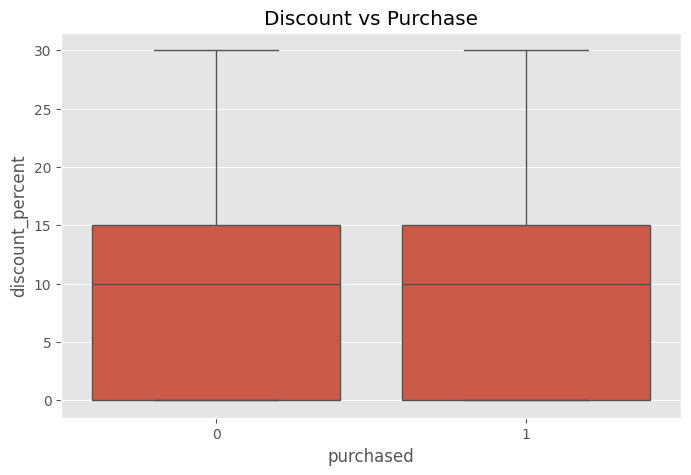

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="purchased",
    y="discount_percent"
)

plt.title("Discount vs Purchase")

plt.show()

In [56]:
pd.crosstab(
    df["added_to_cart"],
    df["purchased"],
    normalize="index"
).round(2) * 100

purchased,0,1
added_to_cart,,
0,100.0,0.0
1,65.0,35.0


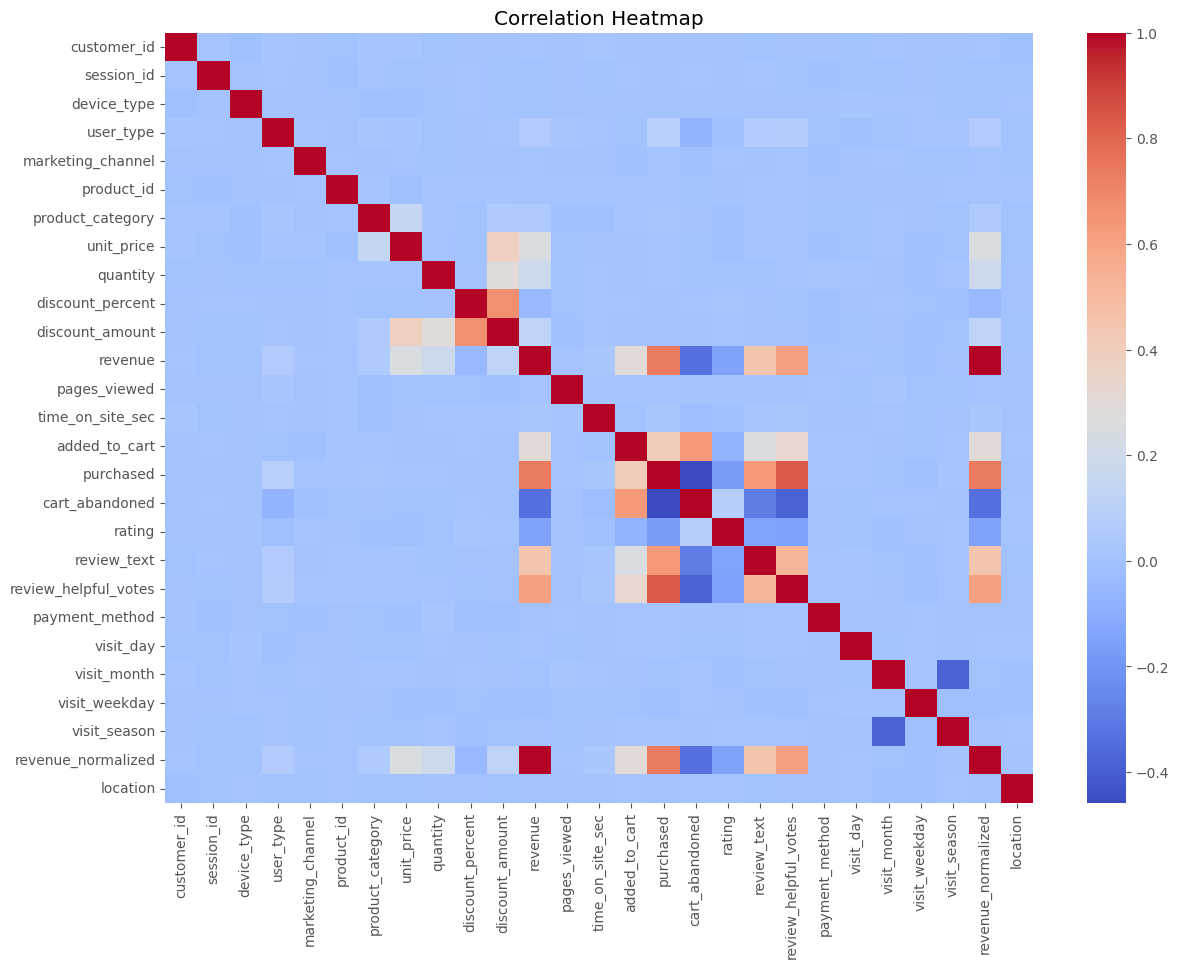

In [57]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

In [59]:
corr_target = df.corr(numeric_only=True)["purchased"].sort_values()

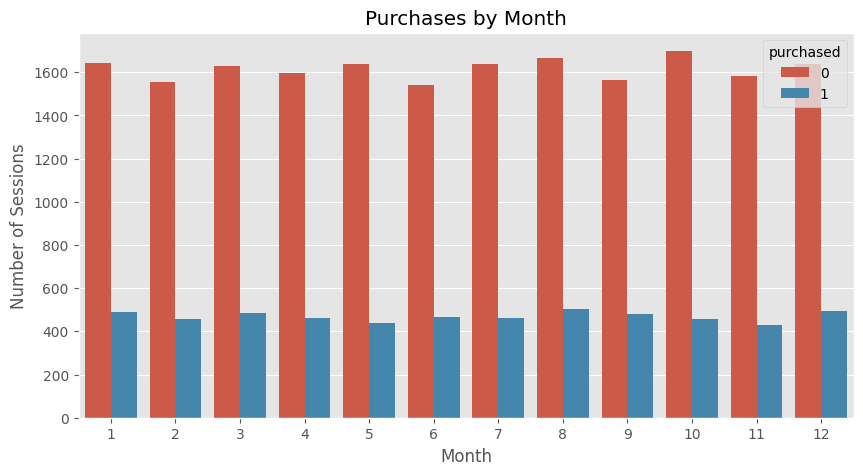

In [63]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="visit_month",
    hue="purchased"
)

plt.title("Purchases by Month")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")

plt.show()

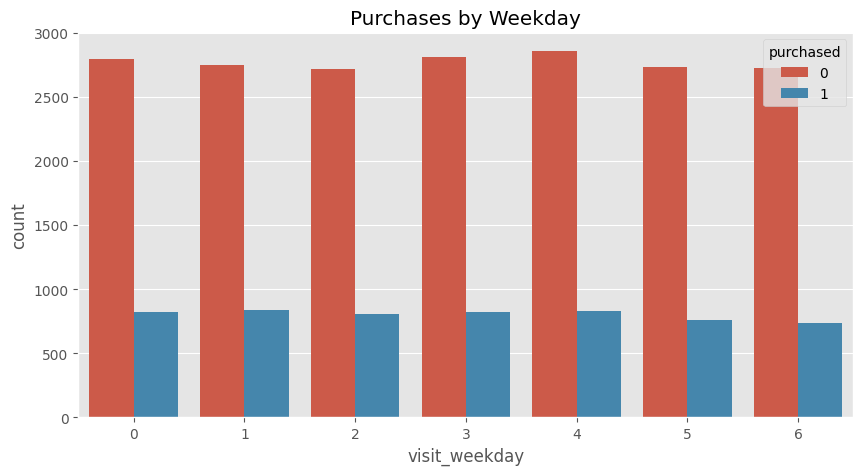

In [64]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="visit_weekday",
    hue="purchased"
)

plt.title("Purchases by Weekday")

plt.show()

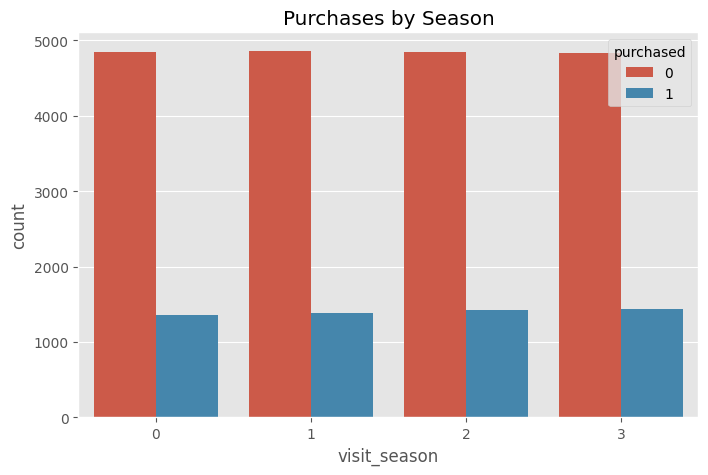

In [65]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="visit_season",
    hue="purchased"
)

plt.title("Purchases by Season")

plt.show()

### Purchase Rate Table

In [66]:
purchase_summary = pd.DataFrame({
    "Purchase Count": df["purchased"].value_counts(),
    "Percentage": df["purchased"].value_counts(normalize=True).mul(100).round(2)
})

purchase_summary

,Purchase Count,Percentage
purchased,,
0,19384,77.54
1,5616,22.46
